# 04. Model Explainability (XAI)

This notebook explores the interpretability of our Credit Scorecard Model. In regulatory environments (e.g., SR 11-7 context), it is crucial to understand both the global drivers of credit risk and the local factors affecting individual loan decisions. We utilize SHAP (SHapley Additive exPlanations) to achieve this transparency.

In [1]:
import logging
import sys
import os
import warnings
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# Ensure src module is importable from notebooks directory
sys.path.append(os.path.abspath('..'))

from src.data.preprocessing import LendingClubLoader
from src.models.scorecard import CreditScorecardModel

warnings.filterwarnings('ignore')
shap.initjs()

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)
logger.info('Initialized Explainability Notebook.')

/home/rei/workspace/VeritasEquilibrium/credit-risk/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-23 12:03:00,548 - __main__ - INFO - Initialized Explainability Notebook.


In [2]:
logger.info('Loading data...')
loader = LendingClubLoader('../data/raw/accepted_2007_to_2018Q4.csv.gz', sample_size=10000, random_seed=42)
df = loader.load_and_clean()
_, X_test, _, y_test = loader.split(test_size=0.2)

model_path = '../artifacts/xgboost_scorecard_v1.joblib'
try:
    logger.info(f'Attempting to load model from {model_path}')
    model = CreditScorecardModel.load(model_path)
except Exception as e:
    logger.warning(f'Could not load model: {e}. Fitting a new model for demonstration purposes.')
    model = CreditScorecardModel(random_state=42)
    model.fit(X_test, y_test)

logger.info('Transforming test data...')
X_test_woe = model.binner.transform(X_test)[model.selected_features_]

2026-05-23 12:03:00,556 - __main__ - INFO - Loading data...
2026-05-23 12:03:00,558 - src.data.preprocessing - INFO - Loading data from ../data/raw/accepted_2007_to_2018Q4.csv.gz
2026-05-23 12:03:26,023 - src.data.preprocessing - INFO - Sampling 10000 records
2026-05-23 12:03:26,190 - src.data.preprocessing - INFO - Cleaning complete. Final shape: (5968, 24)
2026-05-23 12:03:26,191 - src.data.preprocessing - INFO - Class Balance:
2026-05-23 12:03:26,192 - src.data.preprocessing - INFO -   Fully Paid (0): 79.73%
2026-05-23 12:03:26,193 - src.data.preprocessing - INFO -   Charged Off (1): 20.27%
2026-05-23 12:03:26,203 - src.data.preprocessing - INFO - Split complete. Train: 4774, Test: 1194
2026-05-23 12:03:26,205 - __main__ - INFO - Attempting to load model from ../artifacts/xgboost_scorecard_v1.joblib
2026-05-23 12:03:26,507 - src.models.scorecard - INFO - Model successfully loaded from ../artifacts/xgboost_scorecard_v1.joblib
2026-05-23 12:03:26,509 - __main__ - INFO - Transforming t

## Global Explainability

Understanding which features matter most across the entire portfolio.

In [3]:
logger.info('Initializing SHAP TreeExplainer...')
explainer = shap.TreeExplainer(model.model)
shap_values = explainer(X_test_woe)
logger.info('SHAP values computed.')

2026-05-23 12:03:26,582 - __main__ - INFO - Initializing SHAP TreeExplainer...
2026-05-23 12:03:26,933 - __main__ - INFO - SHAP values computed.


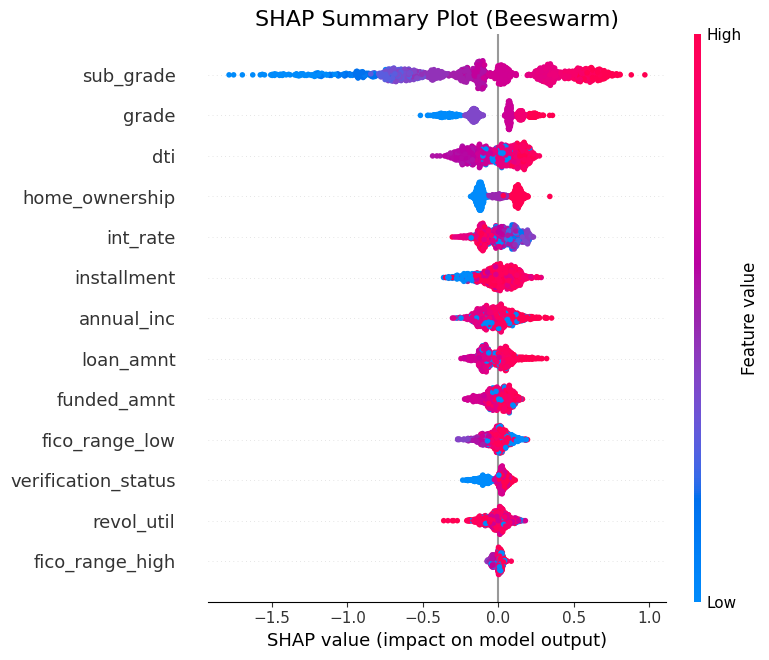

In [4]:
plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot (Beeswarm)', fontsize=16)
shap.summary_plot(shap_values, X_test_woe, show=False)
plt.tight_layout()
plt.show()

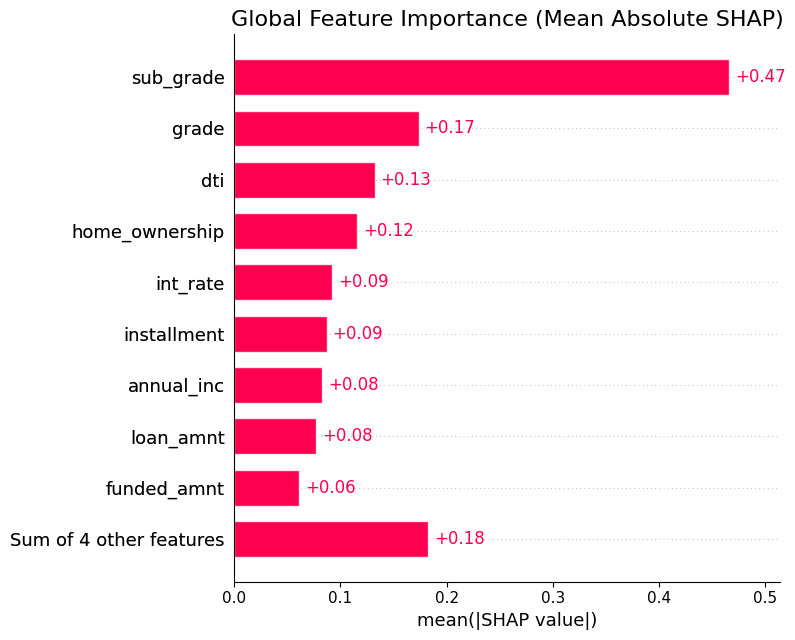

In [5]:
plt.figure(figsize=(10, 8))
plt.title('Global Feature Importance (Mean Absolute SHAP)', fontsize=16)
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.show()

2026-05-23 12:03:27,493 - __main__ - INFO - Top 3 features: ['sub_grade', 'grade', 'dti']


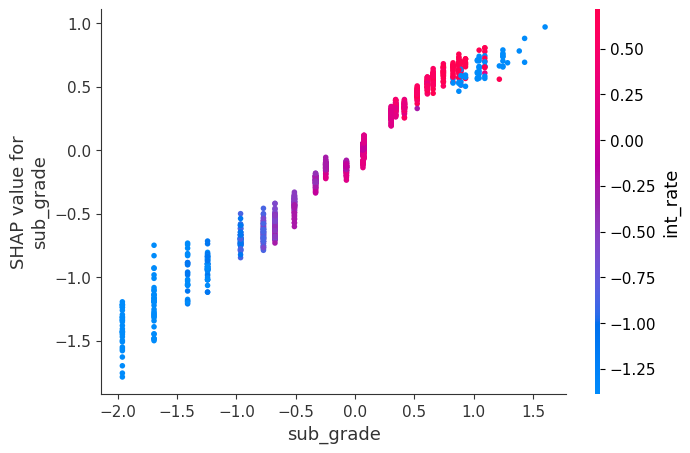

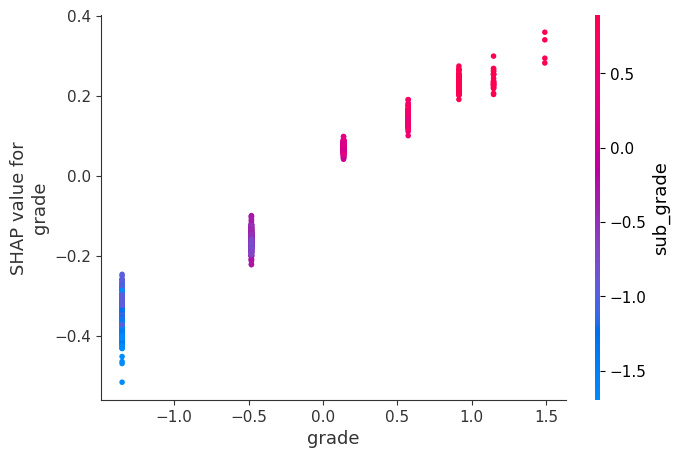

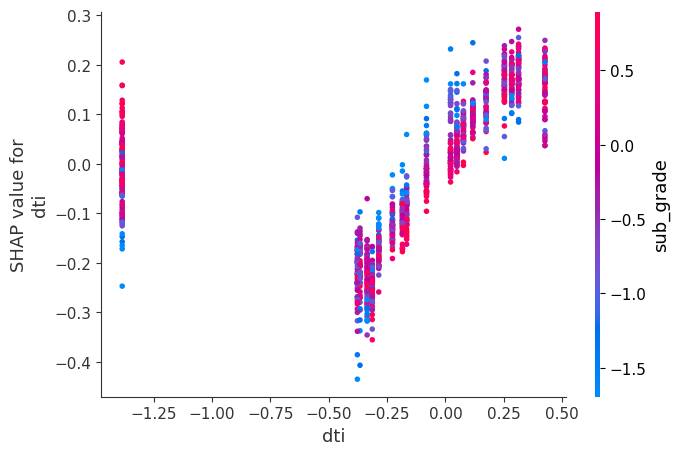

In [6]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_3_idx = np.argsort(mean_abs_shap)[-3:][::-1]
top_3_features = [X_test_woe.columns[i] for i in top_3_idx]

logger.info(f'Top 3 features: {top_3_features}')

for feat in top_3_features:
    shap.dependence_plot(feat, shap_values.values, X_test_woe, interaction_index='auto')

## Local Explainability (Per-Prediction)

Analyzing specific loan applications to see how factors interact to produce an individual score.

In [7]:
probas = model.predict_proba(X_test)[:, 1]

good_idx = np.argmin(probas)
bad_idx = np.argmax(probas)
borderline_idx = np.argmin(np.abs(probas - 0.5))

print(f'Case 1 (Good Applicant) Index: {good_idx} | Predicted Default Prob: {probas[good_idx]:.4f}')
print(f'Case 2 (Bad Applicant) Index: {bad_idx} | Predicted Default Prob: {probas[bad_idx]:.4f}')
print(f'Case 3 (Borderline) Index: {borderline_idx} | Predicted Default Prob: {probas[borderline_idx]:.4f}')

Case 1 (Good Applicant) Index: 199 | Predicted Default Prob: 0.0377
Case 2 (Bad Applicant) Index: 853 | Predicted Default Prob: 0.8892
Case 3 (Borderline) Index: 1152 | Predicted Default Prob: 0.4996


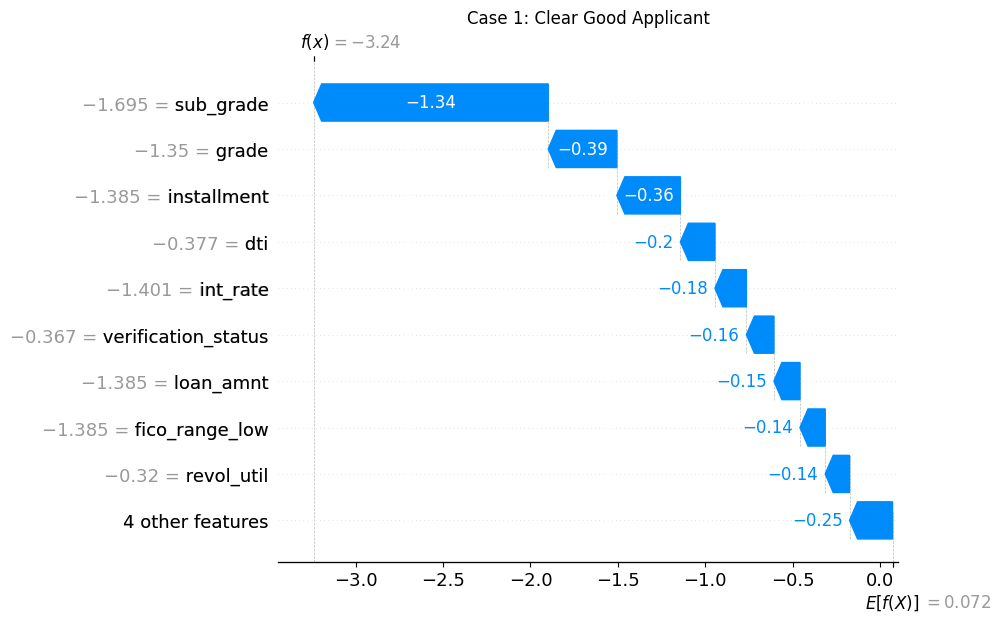

In [8]:
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[good_idx], max_display=10, show=False)
plt.title('Case 1: Clear Good Applicant')
plt.show()

**Interpretation of Case 1 (Good Applicant):**
This profile demonstrates factors strongly decreasing the default probability. The negative SHAP values pull the model's output below the base value.

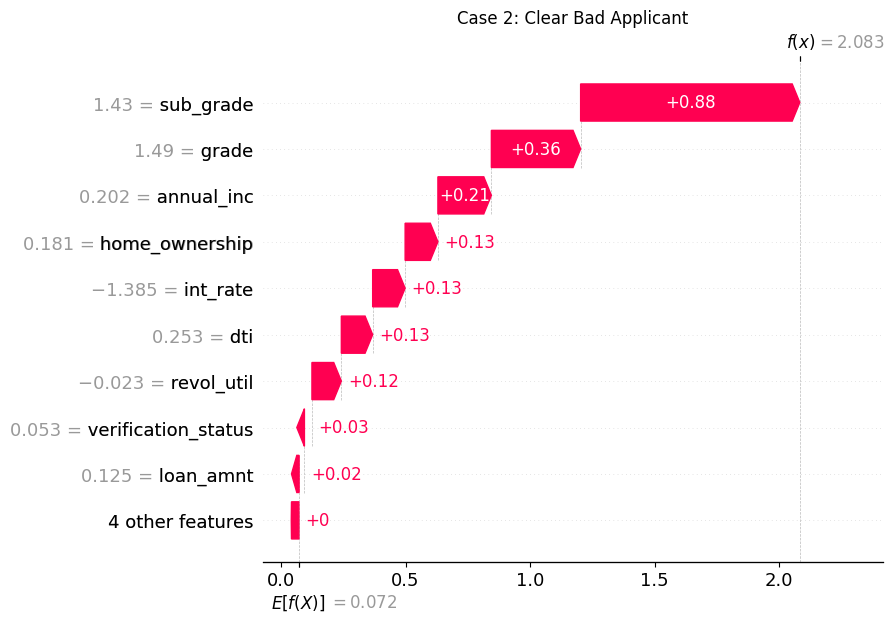

In [9]:
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[bad_idx], max_display=10, show=False)
plt.title('Case 2: Clear Bad Applicant')
plt.show()

**Interpretation of Case 2 (Bad Applicant):**
This profile shows significant risk factors increasing default probability above baseline.

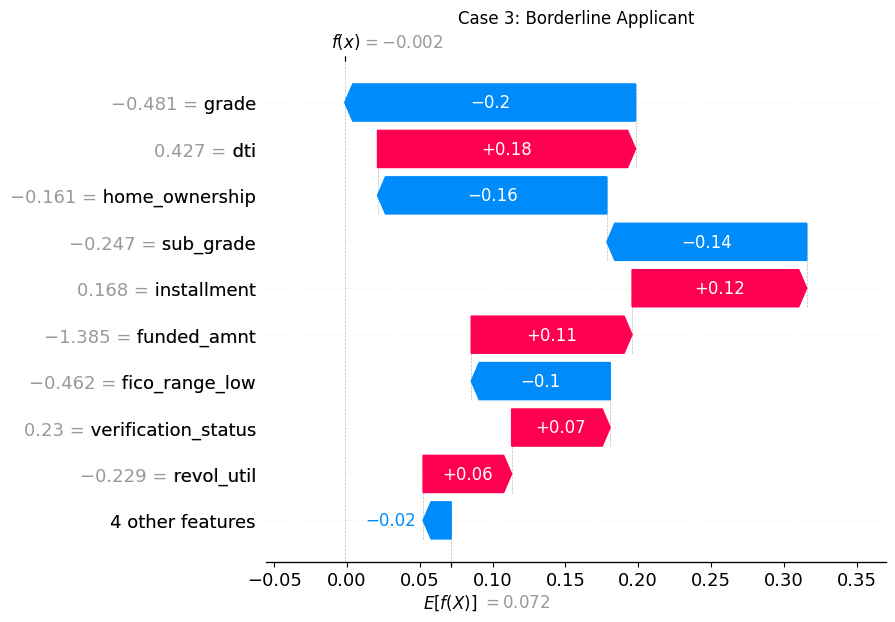

In [10]:
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[borderline_idx], max_display=10, show=False)
plt.title('Case 3: Borderline Applicant')
plt.show()

**Interpretation of Case 3 (Borderline Applicant):**
This profile presents mixed drivers that push prediction near the decision threshold.